In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost scikit-learn matplotlib pandas numpy scipy pyarrow requests --quiet

In [3]:
# Clean feature space (ip.proto dropped). UAV-NIDD subsampled to 300k for memory; UAVIDS full.
# Summaries (mean+/-std, decomposition, sensitivity index) are stable at this size.
DATASETS=[
 {"name":"UAVIDS-2025","kind":"zenodo","record":"15336998","data_dir":"data/uavids2025",
  "label_col":"label","normal_value":"Normal Traffic","include_families":None,"subsample_n":None,
  "drops":["unnamed","flowid","srcaddr","dstaddr","srcport","dstport","index","timestamp"]},
 {"name":"UAV-NIDD","kind":"file","file":"data/uav_nidd/UAV-NDD CSV/UAV-Case1-Label.csv",
  "parquet":"data/uav_nidd/case1.parquet","data_dir":"data/uav_nidd","label_col":"Label",
  "normal_value":"Normal","include_families":["DDoS","UDP Flooding","MITM","Jamming","BruteForce","De-authentication"],
  "subsample_n":300000,
  "drops":["unnamed","index","ip.src","ip.dst","ip.proto","wlan.tag","srcport","dstport","udp.srcport","udp.dstport",
           "frame.time","frame.number","time_epoch","time_relative","time_delta","bssid","mactime",
           "vendor_oui","wlan_radio.timestamp","wlan_radio.start_tsf","radiotap.timestamp","wlan.seq"]},
]
CFG={"seeds":list(range(10)),"alpha":0.10,"nbins":15,
     "normal_fracs":{"train":0.60,"cal":0.20,"test_seen":0.10,"test_shift":0.10},
     "family_fracs":{"train":0.60,"cal":0.20,"test_seen":0.20},
     "xgb":{"n_estimators":300,"max_depth":6,"learning_rate":0.1,"subsample":0.9,"colsample_bytree":0.9,"tree_method":"hist"},
     "fig_dir":"figures","report_dir":"reports"}
for d in [CFG["fig_dir"],CFG["report_dir"]]: os.makedirs(d,exist_ok=True)
print("configured")

configured


In [4]:
import numpy as np, pandas as pd, requests, glob, zipfile, importlib, gc, src.data
importlib.reload(src.data)
import matplotlib.pyplot as plt, xgboost as xgb
from sklearn.metrics import balanced_accuracy_score
from src.data import load_csvs, detect_schema, prepare_splits
from src.trust import top_label_ece, brier_binary, conformal_qhat, aurc, logit, fit_calibrators, apply_calibrators

def load_dataset(spec):
    dd=spec["data_dir"]; os.makedirs(dd,exist_ok=True)
    if spec["kind"]=="zenodo":
        if not glob.glob(dd+"/**/*.csv",recursive=True):
            meta=requests.get(f"https://zenodo.org/api/records/{spec['record']}",timeout=60).json()
            for f in meta.get("files",[]):
                n,u=f["key"],f["links"]["self"]
                if n.lower().endswith((".csv",".zip",".gz")): open(os.path.join(dd,n),"wb").write(requests.get(u,timeout=1200).content)
            for z in glob.glob(dd+"/*.zip"): zipfile.ZipFile(z).extractall(dd)
        df=load_csvs(dd); lc,nv,fams=detect_schema(df,spec["label_col"],spec["normal_value"])
    else:
        pq=spec.get("parquet")
        df=pd.read_parquet(pq) if pq and os.path.exists(pq) else pd.read_csv(spec["file"],low_memory=False,encoding="latin-1")
        lc,nv=spec["label_col"],spec["normal_value"]; fams=[v for v in df[lc].unique() if v!=nv]
    if spec.get("subsample_n") and len(df)>spec["subsample_n"]:
        df=df.groupby(lc,group_keys=False).sample(frac=spec["subsample_n"]/len(df),random_state=42).reset_index(drop=True)
    if spec.get("include_families"):
        df=df[df[lc].isin([nv]+list(spec["include_families"]))].reset_index(drop=True); fams=list(spec["include_families"])
    return df,lc,nv,fams

def cov_and_sets(p,y,qhat):
    p=np.asarray(p); y=np.asarray(y)
    in_attack=(1-p)<=qhat; in_normal=p<=qhat
    empty=(~in_attack)&(~in_normal); both=in_attack&in_normal
    attack_only=in_attack&(~in_normal); normal_only=in_normal&(~in_attack)
    inset=np.where(y==1,in_attack,in_normal); size=in_attack.astype(int)+in_normal.astype(int)
    marg=float(inset.mean()); bal=float(np.mean([inset[y==k].mean() for k in np.unique(y)]))
    return dict(marg=marg,bal=bal,size=float(size.mean()),empty=float(empty.mean()),
                normal_only=float(normal_only.mean()),attack_only=float(attack_only.mean()),both=float(both.mean()))
print("helpers ready")

helpers ready


In [5]:
# Panel per (family, seed): split calibration; raw scores for conformal; full metrics + set decomposition.
# float32 matrices + explicit frees keep memory bounded.
def panel_once(df,lc,nv,F,seed,spec):
    S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
    for k in ["X_train","X_cal","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
    clf=xgb.XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=seed,**CFG["xgb"]).fit(S["X_train"],S["y_train"])
    Xc,yc=S["X_cal"],S["y_cal"]; perm=np.random.default_rng(seed).permutation(len(yc)); h=len(yc)//2; ip,ic=perm[:h],perm[h:]
    pr=lambda X: clf.predict_proba(X)[:,1]
    p_pc=pr(Xc[ip]); p_cc=pr(Xc[ic]); p_seen=pr(S["X_seen"]); p_shift=pr(S["X_shift"])
    ys,yh=S["y_seen"],S["y_shift"]
    fitted=fit_calibrators(logit(p_pc),p_pc,yc[ip]); ch=apply_calibrators(fitted,logit(p_shift),p_shift); cs=apply_calibrators(fitted,logit(p_seen),p_seen)
    qhat=conformal_qhat(p_cc,yc[ic],alpha=CFG["alpha"])
    sh=cov_and_sets(p_shift,yh,qhat); se=cov_and_sets(p_seen,ys,qhat)
    r={"dataset":spec["name"],"held_out":str(F),"seed":seed,
       "shift_balacc":balanced_accuracy_score(yh,(p_shift>=.5).astype(int)),
       "seen_balacc":balanced_accuracy_score(ys,(p_seen>=.5).astype(int)),
       "shift_ECE":top_label_ece(ch["temperature"],yh,CFG["nbins"]),"seen_ECE":top_label_ece(cs["temperature"],ys,CFG["nbins"]),
       "shift_Brier":brier_binary(ch["temperature"],yh),
       "shift_cov_marg":sh["marg"],"shift_cov_bal":sh["bal"],"seen_cov_marg":se["marg"],
       "shift_setsize":sh["size"],
       "shift_AURC":aurc(np.maximum(p_shift,1-p_shift),((p_shift>=.5).astype(int)==yh).astype(float))[0],
       "seen_AURC":aurc(np.maximum(p_seen,1-p_seen),((p_seen>=.5).astype(int)==ys).astype(float))[0],
       "set_empty":sh["empty"],"set_normal_only":sh["normal_only"],"set_attack_only":sh["attack_only"],"set_both":sh["both"]}
    del S,clf,p_pc,p_cc,p_seen,p_shift; gc.collect()
    return r

rows=[]
for spec in DATASETS:
    df,lc,nv,fams=load_dataset(spec)
    S0=prepare_splits(df,lc,nv,fams[0],spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],0)
    print(spec["name"],"rows",len(df),"features",S0["X_train"].shape[1]); del S0; gc.collect()
    for seed in CFG["seeds"]:
        for F in fams:
            rows.append(panel_once(df,lc,nv,F,seed,spec)); gc.collect()
        print(spec["name"],"seed",seed,"done")
    del df; gc.collect()
panel=pd.DataFrame(rows); panel.to_csv(os.path.join(CFG["report_dir"],"10_unified_panel_raw.csv"),index=False)
print("rows:",len(panel))

UAVIDS-2025 rows 122171 features 16
UAVIDS-2025 seed 0 done
UAVIDS-2025 seed 1 done
UAVIDS-2025 seed 2 done
UAVIDS-2025 seed 3 done
UAVIDS-2025 seed 4 done
UAVIDS-2025 seed 5 done
UAVIDS-2025 seed 6 done
UAVIDS-2025 seed 7 done
UAVIDS-2025 seed 8 done
UAVIDS-2025 seed 9 done
UAV-NIDD rows 253322 features 51
UAV-NIDD seed 0 done
UAV-NIDD seed 1 done
UAV-NIDD seed 2 done
UAV-NIDD seed 3 done
UAV-NIDD seed 4 done
UAV-NIDD seed 5 done
UAV-NIDD seed 6 done
UAV-NIDD seed 7 done
UAV-NIDD seed 8 done
UAV-NIDD seed 9 done
rows: 100


In [6]:
# TABLE: trust panel mean +/- std per family (single consistent run)
def ms(g,col): return "%.3f \u00b1 %.3f"%(g[col].mean(),g[col].std())
agg=[]
for (ds,F),g in panel.groupby(["dataset","held_out"]):
    agg.append({"dataset":ds,"held_out":F,
        "bal_acc":ms(g,"shift_balacc"),"ECE":ms(g,"shift_ECE"),"Brier":ms(g,"shift_Brier"),
        "cov_marg":ms(g,"shift_cov_marg"),"cov_bal":ms(g,"shift_cov_bal"),
        "set_size":ms(g,"shift_setsize"),"AURC":ms(g,"shift_AURC")})
A=pd.DataFrame(agg); pd.set_option("display.width",220,"display.max_columns",20)
print(A.to_string(index=False)); A.to_csv(os.path.join(CFG["report_dir"],"10_panel_mean_std.csv"),index=False)

    dataset          held_out       bal_acc           ECE         Brier      cov_marg       cov_bal      set_size          AURC
   UAV-NIDD        BruteForce 0.998 ± 0.001 0.001 ± 0.000 0.001 ± 0.000 0.656 ± 0.035 0.422 ± 0.040 0.656 ± 0.035 0.000 ± 0.000
   UAV-NIDD              DDoS 0.969 ± 0.017 0.051 ± 0.027 0.044 ± 0.027 0.065 ± 0.075 0.053 ± 0.038 0.065 ± 0.075 0.005 ± 0.004
   UAV-NIDD De-authentication 0.998 ± 0.001 0.000 ± 0.000 0.000 ± 0.000 0.285 ± 0.197 0.171 ± 0.110 0.285 ± 0.197 0.000 ± 0.000
   UAV-NIDD           Jamming 0.969 ± 0.008 0.047 ± 0.014 0.045 ± 0.010 0.001 ± 0.001 0.010 ± 0.014 0.001 ± 0.001 0.009 ± 0.006
   UAV-NIDD              MITM 0.995 ± 0.003 0.004 ± 0.002 0.004 ± 0.002 0.151 ± 0.316 0.099 ± 0.179 0.151 ± 0.316 0.001 ± 0.000
   UAV-NIDD      UDP Flooding 0.998 ± 0.001 0.000 ± 0.000 0.000 ± 0.000 0.802 ± 0.038 0.434 ± 0.039 0.802 ± 0.038 0.000 ± 0.000
UAVIDS-2025  Blackhole Attack 0.731 ± 0.019 0.405 ± 0.043 0.390 ± 0.039 0.408 ± 0.001 0.599 ± 0.005 0.40

In [7]:
# TABLE: prediction-set decomposition on the shifted family (mean over seeds)
dec=panel.groupby(["dataset","held_out"])[["set_empty","set_normal_only","set_attack_only","set_both","shift_cov_marg"]].mean().round(3)
dec.columns=["empty","{normal}","{attack}","{both}","coverage(marg)"]
print("Prediction-set composition on shifted family (fractions):")
print(dec.to_string()); dec.to_csv(os.path.join(CFG["report_dir"],"10_prediction_set_decomposition.csv"))

Prediction-set composition on shifted family (fractions):
                               empty  {normal}  {attack}  {both}  coverage(marg)
dataset     held_out                                                            
UAV-NIDD    BruteForce         0.344     0.002     0.654     0.0           0.656
            DDoS               0.935     0.000     0.065     0.0           0.065
            De-authentication  0.715     0.003     0.282     0.0           0.285
            Jamming            0.999     0.001     0.000     0.0           0.001
            MITM               0.849     0.001     0.150     0.0           0.151
            UDP Flooding       0.198     0.001     0.801     0.0           0.802
UAVIDS-2025 Blackhole Attack   0.592     0.076     0.332     0.0           0.408
            Flooding Attack    0.282     0.096     0.622     0.0           0.718
            Sybil Attack       0.088     0.081     0.830     0.0           0.912
            Wormhole Attack    0.357     0.083     

In [8]:
# QUANTITATIVE SENSITIVITY INDEX: how much each signal degrades seen->shift, per dataset
g=panel.groupby(["dataset","held_out"]).mean(numeric_only=True).reset_index()
g["acc_err_gain"]=(1-g["shift_balacc"])-(1-g["seen_balacc"])
g["ece_gain"]=g["shift_ECE"]-g["seen_ECE"]
g["cov_loss"]=(0.90-g["shift_cov_marg"]).clip(lower=0)
g["aurc_gain"]=g["shift_AURC"]-g["seen_AURC"]
def flags(sub):
    return pd.Series({
      "coverage: families below 0.80 marg":int((sub["shift_cov_marg"]<0.80).sum()),
      "accuracy: families below 0.90 balacc":int((sub["shift_balacc"]<0.90).sum()),
      "ECE: families above 0.10":int((sub["shift_ECE"]>0.10).sum()),
      "AURC: families above 0.05":int((sub["shift_AURC"]>0.05).sum()),
      "mean coverage shortfall":round(sub["cov_loss"].mean(),3),
      "mean ECE gain":round(sub["ece_gain"].mean(),3),
      "mean accuracy-error gain":round(sub["acc_err_gain"].mean(),3)})
sens=g.groupby("dataset").apply(flags)
print("Sensitivity of each trust signal under shift (higher count/value = signal detects the shift on more families):")
print(sens.T.to_string()); sens.T.to_csv(os.path.join(CFG["report_dir"],"10_sensitivity_index.csv"))

/tmp/ipykernel_652/3789647868.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sens=g.groupby("dataset").apply(flags)


Sensitivity of each trust signal under shift (higher count/value = signal detects the shift on more families):
dataset                               UAV-NIDD  UAVIDS-2025
coverage: families below 0.80 marg       5.000        3.000
accuracy: families below 0.90 balacc     0.000        1.000
ECE: families above 0.10                 0.000        2.000
AURC: families above 0.05                0.000        1.000
mean coverage shortfall                  0.573        0.235
mean ECE gain                            0.017        0.142
mean accuracy-error gain                 0.010        0.089


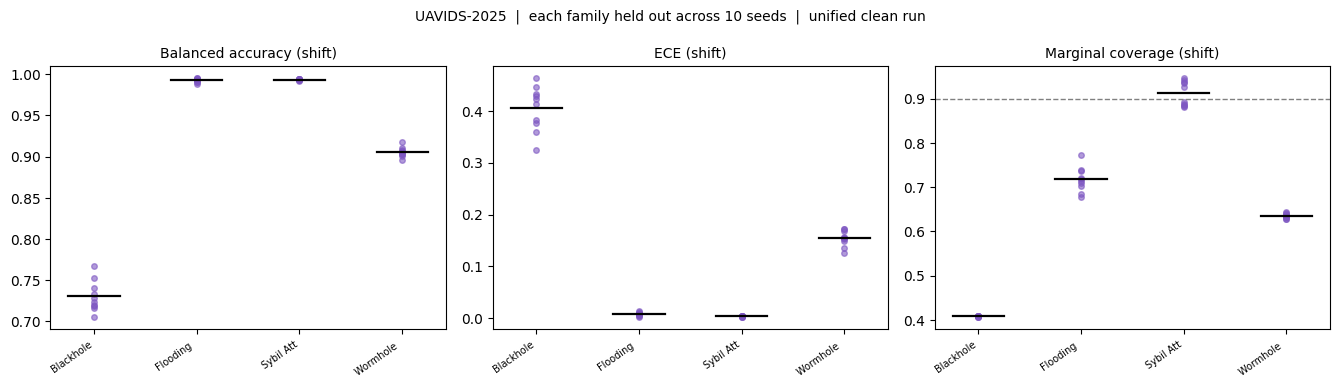

wrote 03_seed_spread.png


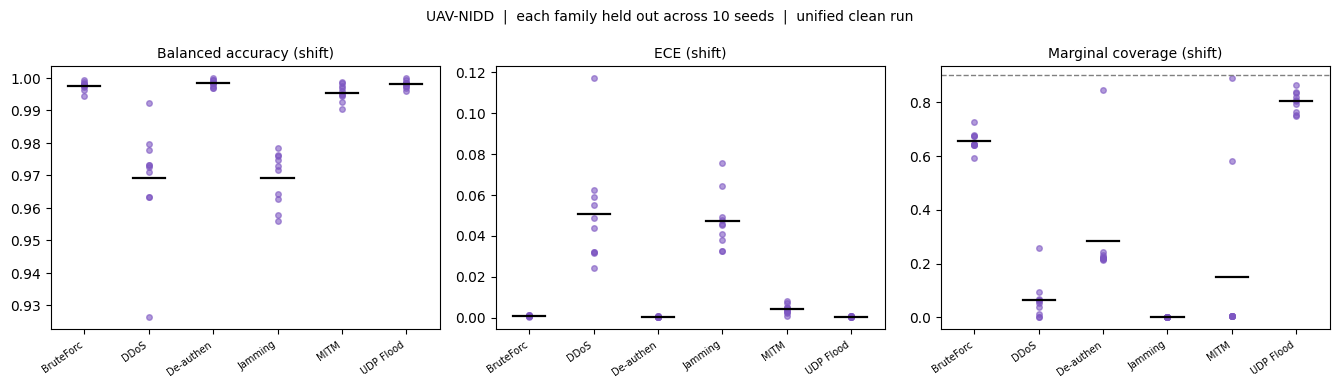

wrote 04_uavnidd_seed_spread.png


In [9]:
# REGENERATE the two trust figures from THIS run so figures match tables (marginal coverage = guaranteed quantity)
for name_ds in ["UAVIDS-2025","UAV-NIDD"]:
    sub=panel[panel["dataset"]==name_ds]; fams=sorted(sub["held_out"].unique())
    fig,ax=plt.subplots(1,3,figsize=(13.5,3.9))
    for a,(col,ttl,line) in zip(ax,[("shift_balacc","Balanced accuracy (shift)",None),("shift_ECE","ECE (shift)",None),("shift_cov_marg","Marginal coverage (shift)",0.90)]):
        for i,F in enumerate(fams):
            v=sub[sub["held_out"]==F][col].values; a.scatter([i]*len(v),v,s=16,alpha=.6,color="#7e57c2")
            a.plot([i-.25,i+.25],[v.mean()]*2,color="black",lw=1.6)
        if line is not None: a.axhline(line,ls="--",color="gray",lw=1)
        a.set_xticks(range(len(fams))); a.set_xticklabels([f[:9] for f in fams],rotation=35,ha="right",fontsize=7); a.set_title(ttl,fontsize=10)
    fig.suptitle(name_ds+"  |  each family held out across 10 seeds  |  unified clean run",fontsize=10); fig.tight_layout()
    name="03_seed_spread.png" if name_ds=="UAVIDS-2025" else "04_uavnidd_seed_spread.png"
    fig.savefig(os.path.join(CFG["fig_dir"],name),dpi=150,bbox_inches="tight"); plt.show(); print("wrote",name)

In [10]:
# Commit
!git add reports/ figures/ notebooks/
!git commit -m "10 unified panel: single clean run (ip.proto dropped, UAV-NIDD 300k, 10 seeds) -> mean+/-std, set size, prediction-set decomposition, sensitivity index; regenerated trust figures"
!git push origin main

[main 7db4b98] 10 unified panel: single clean run (ip.proto dropped, UAV-NIDD 300k, 10 seeds) -> mean+/-std, set size, prediction-set decomposition, sensitivity index; regenerated trust figures
 7 files changed, 119 insertions(+), 119 deletions(-)
 rewrite figures/04_uavnidd_seed_spread.png (98%)
 rewrite notebooks/10_unified_panel.ipynb (99%)
 rewrite notebooks/consistency_setup.ipynb (100%)
 rewrite reports/10_unified_panel_raw.csv (69%)
Enumerating objects: 23, done.
Counting objects: 100% (23/23), done.
Delta compression using up to 8 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 94.52 KiB | 4.11 MiB/s, done.
Total 12 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
To https://github.com/anasbiswas1/uav-trust-research.git
   383fed5..7db4b98  main -> main
